In [1]:
from functions import *
from minerva.data.datasets import SimpleDataset
from minerva.data.readers import TiffReader, PNGReader

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cap_list = [1, 2, 3, 5, 10, 20, 0.01, 0.016, 0.028, 0.046, 0.077, 0.1, 0.129, 0.215, 0.359, 0.599, 1.0]

In [3]:
image_path = "/workspaces/shared_data/seismic/f3_segmentation/images"
label_path = "/workspaces/shared_data/seismic/f3_segmentation/annotations"

In [4]:
# image_path = "/workspaces/shared_data/seam_ai_datasets/seam_ai/images"
# label_path = "/workspaces/shared_data/seam_ai_datasets/seam_ai/annotations"

In [5]:
train_data_reader = TiffReader(path=f"{image_path}/train")
train_label_reader = PNGReader(path=f"{label_path}/train")

In [6]:
datamodule_list = []

train_dataset = SimpleDataset(
    readers=[
        train_data_reader,
        train_label_reader,
    ],
    return_single=False,
)

for cap in cap_list:
    aux = CapDataModule(
        train_dataset=train_dataset,
        cap_train=cap,
        
    )
    datamodule_list.append(aux)

In [7]:
for datamodule in datamodule_list:
    print(len(datamodule.train_dataloader()))
    

2
2
3
5
10
20
9
15
27
45
76
99
127
213
356
594
992


In [8]:
!pwd

/workspaces/Seismic-Byol/dev-seismic-byol


In [9]:
import glob
import os

# Retrieve all CSV files in subfolders of a directory
csv_files = glob.glob('/logs/pretrain/3/**/**/*.csv', recursive=True)
print(csv_files)

# Store the first file's name (if it exists) in a variable
name = os.path.basename(csv_files[0]) if csv_files else None
print(name)

[]
None


In [10]:
import os

def retrieve_csvs(base_dir, number):
    result = []
    root_dir = os.path.join(base_dir, str(number))

    for dirpath, _, filenames in os.walk(root_dir):
        for file in filenames:
            if file.endswith(".csv"):
                model_name = os.path.basename(os.path.dirname(dirpath))  # one folder above the CSV
                full_path = os.path.join(dirpath, file)
                result.append((model_name, full_path))

    return result

# Example usage:
csvs = retrieve_csvs("path/to/pretrain", 0)
for model_name, csv_path in csvs:
    print(f"{model_name} : {csv_path}")


In [11]:
base_dir = 'logs/pretrain/'

csv_paths = retrieve_csvs(base_dir, 3)

In [12]:
csv_paths[0]

('V3_pretrain_both_In256_B32_E500',
 'logs/pretrain/3/V3_pretrain_both_In256_B32_E500/both/V3_pretrain_both_In256_B32_E500/both/metrics.csv')

In [13]:
import csv
from pathlib import Path
import re
import argparse

def extract_model_metadata(model_name):
    match = re.match(r"V(\d+)_pretrain_(.+?)_In(.+?)_B(.+)_E(.+)", model_name)
    if not match:
        raise ValueError(f"Invalid model name format: {model_name}")
    repetition, pretrain_data, input_size, batch_size, epochs = match.groups()
    return {
        "model_name": model_name,
        "repetition": repetition,
        "pretrain_data": pretrain_data,
        }

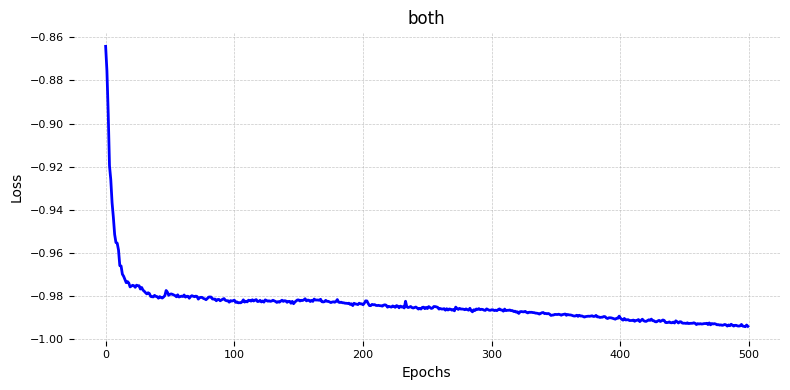

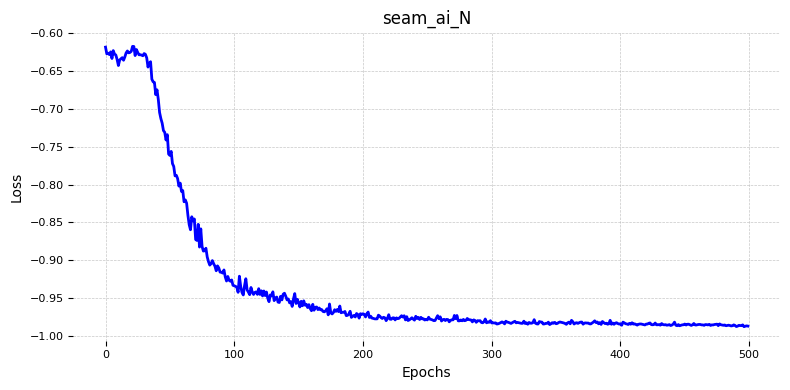

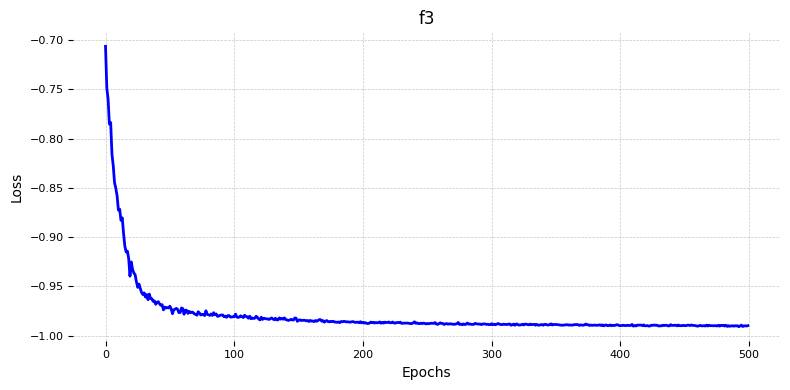

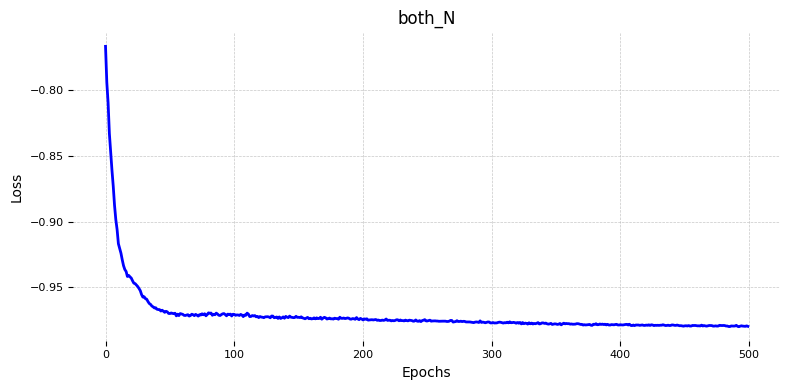

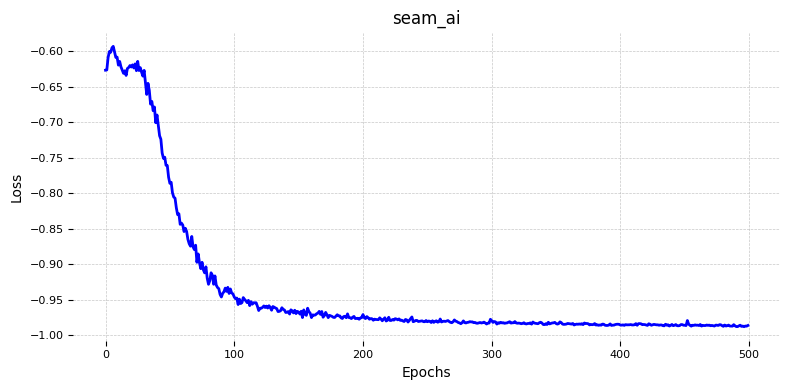

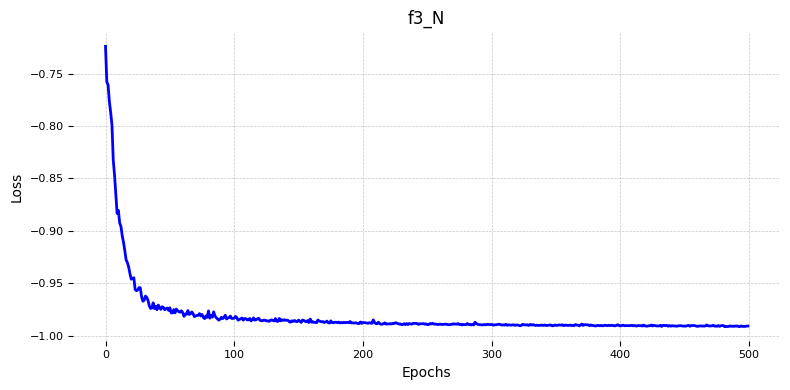

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

for item in csv_paths:
    name = extract_model_metadata(item[0])['pretrain_data']
    path = item[1] 

    df = pd.read_csv(path)

    # Convert to numeric just in case
    df['epoch'] = pd.to_numeric(df['epoch'], errors='coerce')
    df['train_loss'] = pd.to_numeric(df['train_loss'], errors='coerce')

    # Plot
    plt.figure(figsize=(8, 4))
    plt.plot(df['epoch'], df['train_loss'], color='blue', linewidth=2)

    # Minimal axis formatting
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{name}')
    plt.box(False)
    plt.savefig(f'outputs/curves/loss_curve_{name}')

    plt.tight_layout()
    plt.show()
